In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

Libraries imported successfully.


In [ ]:
from pathlib import Path
import pandas as pd

TRAIN_PATH = Path("../data/raw/train.csv")
TEST_PATH = Path("../data/raw/test.csv")

print("Checking dataset files...")

if not TRAIN_PATH.exists():
    raise FileNotFoundError(f"Training file not found: {TRAIN_PATH}")

if not TEST_PATH.exists():
    raise FileNotFoundError(f"Test file not found: {TEST_PATH}")

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Dataset loaded successfully!\n")

print(f"Training samples: {len(train_df):,}")
print(f"Test samples: {len(test_df):,}")

Checking dataset files...
Dataset loaded successfully!

Training samples: 10,003
Test samples: 3,080


In [ ]:
train_df = train_df.rename(columns={"category": "label"})
test_df = test_df.rename(columns={"category": "label"})

print("Column names standardized:")
print(train_df.columns.tolist())

Column names standardized:
['text', 'label']


In [4]:
print("TRAINING DATA")
print("=" * 60)

print("\nShape:")
print(train_df.shape)

print("\nColumns:")
print(train_df.columns.tolist())

print("\nData types:")
print(train_df.dtypes)

print("\nFirst 5 rows:")
display(train_df.head())

TRAINING DATA

Shape:
(10003, 2)

Columns:
['text', 'label']

Data types:
text     str
label    str
dtype: object

First 5 rows:


,text,label
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived after 2 weeks?,card_arrival
2,I have been waiting over a week. Is the card still coming?,card_arrival
3,Can I track my card while it is in the process of delivery?,card_arrival
4,"How do I know if I will get my card, or if it is lost?",card_arrival


In [5]:
print("TEST DATA")
print("=" * 60)

print("\nShape:")
print(test_df.shape)

print("\nColumns:")
print(test_df.columns.tolist())

print("\nFirst 5 rows:")
display(test_df.head())

TEST DATA

Shape:
(3080, 2)

Columns:
['text', 'label']

First 5 rows:


,text,label
0,How do I locate my card?,card_arrival
1,"I still have not received my new card, I ordered over a week ago.",card_arrival
2,I ordered a card but it has not arrived. Help please!,card_arrival
3,Is there a way to know when my card will arrive?,card_arrival
4,My card has not arrived yet.,card_arrival


In [6]:
print("MISSING VALUE ANALYSIS")
print("=" * 60)

train_missing = train_df.isnull().sum()
test_missing = test_df.isnull().sum()

print("\nTraining dataset:")
display(train_missing.to_frame("missing_values"))

print("\nTest dataset:")
display(test_missing.to_frame("missing_values"))

MISSING VALUE ANALYSIS

Training dataset:


,missing_values
text,0
label,0



Test dataset:


,missing_values
text,0
label,0


In [7]:
print("DUPLICATE ANALYSIS")
print("=" * 60)

train_duplicates = train_df.duplicated().sum()
test_duplicates = test_df.duplicated().sum()

train_text_duplicates = train_df["text"].duplicated().sum()
test_text_duplicates = test_df["text"].duplicated().sum()

print(f"Duplicate rows in training set: {train_duplicates}")
print(f"Duplicate rows in test set: {test_duplicates}")

print(f"\nDuplicate text entries in training set: {train_text_duplicates}")
print(f"Duplicate text entries in test set: {test_text_duplicates}")

DUPLICATE ANALYSIS
Duplicate rows in training set: 0
Duplicate rows in test set: 0

Duplicate text entries in training set: 0
Duplicate text entries in test set: 0


In [8]:
intent_counts = train_df["label"].value_counts()

print("INTENT ANALYSIS")
print("=" * 60)

print(f"Number of unique intents: {train_df['label'].nunique()}")

print("\nTop 10 most frequent intents:")
display(intent_counts.head(10).to_frame("count"))

print("\nBottom 10 least frequent intents:")
display(intent_counts.tail(10).to_frame("count"))

INTENT ANALYSIS
Number of unique intents: 77

Top 10 most frequent intents:


,count
label,
card_payment_fee_charged,187
direct_debit_payment_not_recognised,182
balance_not_updated_after_cheque_or_cash_deposit,181
wrong_amount_of_cash_received,180
cash_withdrawal_charge,177
transaction_charged_twice,175
declined_cash_withdrawal,173
transfer_fee_charged,172
transfer_not_received_by_recipient,171



Bottom 10 least frequent intents:


,count
label,
top_up_limits,97
get_disposable_virtual_card,97
receiving_money,95
atm_support,87
compromised_card,86
lost_or_stolen_card,82
card_swallowed,61
card_acceptance,59
virtual_card_not_working,41


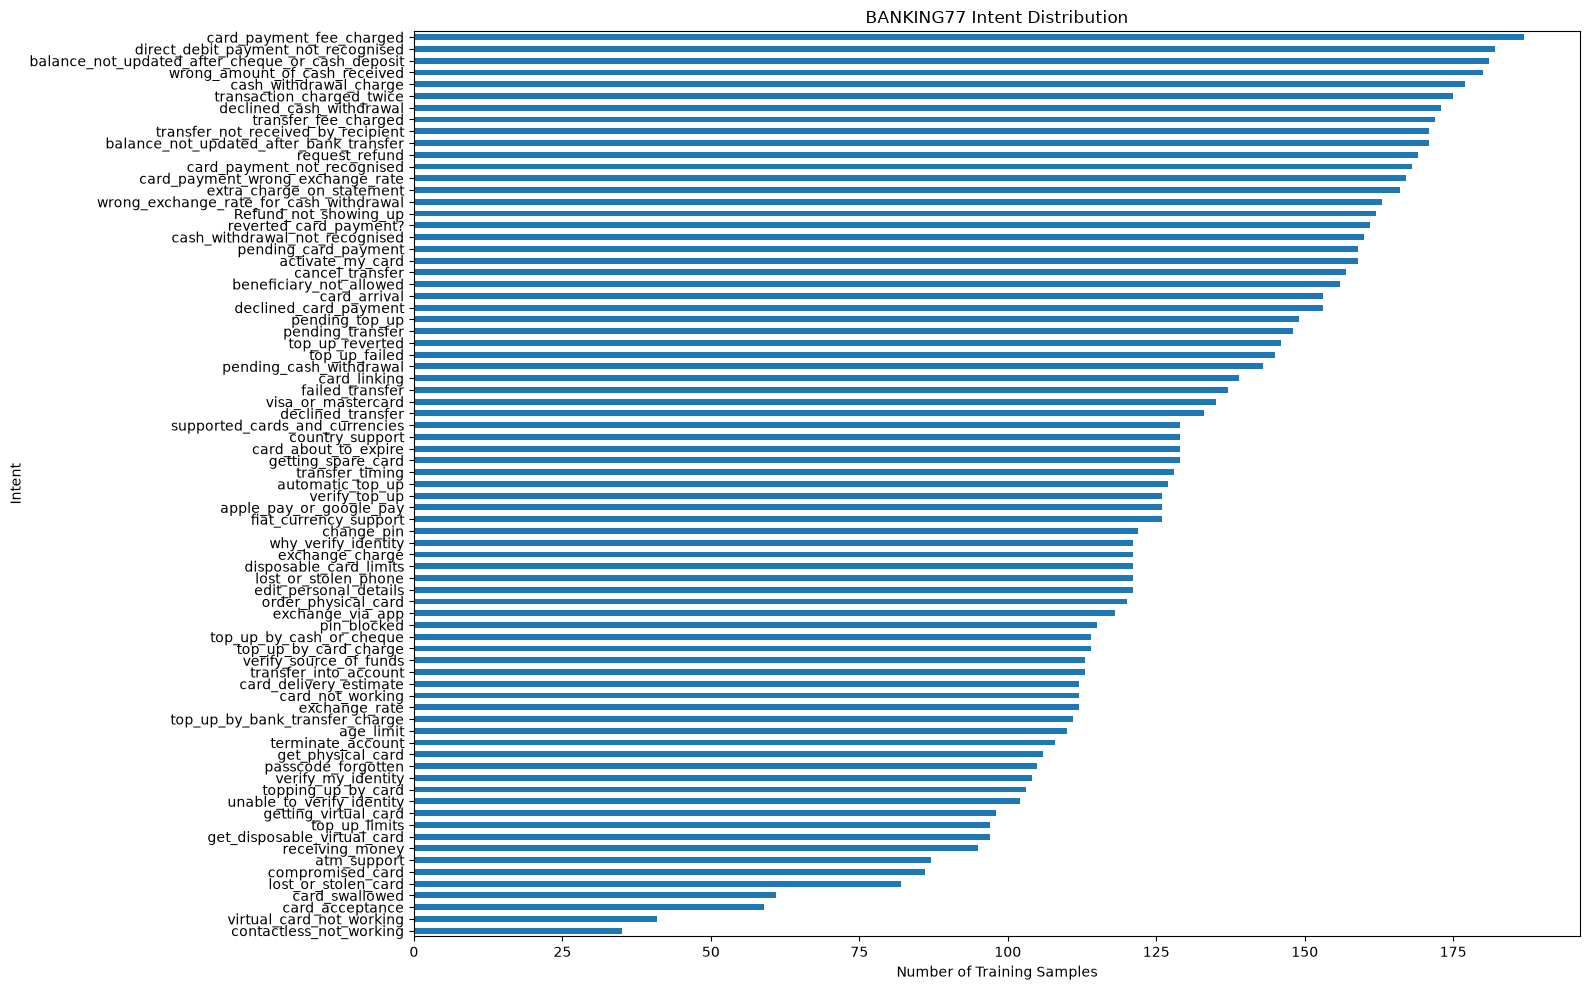

In [9]:
plt.figure(figsize=(16, 10))

intent_counts.sort_values().plot(kind="barh")

plt.title("BANKING77 Intent Distribution")
plt.xlabel("Number of Training Samples")
plt.ylabel("Intent")

plt.tight_layout()
plt.show()

In [10]:
print("CLASS BALANCE ANALYSIS")
print("=" * 60)

print(f"Minimum samples in an intent: {intent_counts.min()}")
print(f"Maximum samples in an intent: {intent_counts.max()}")
print(f"Mean samples per intent: {intent_counts.mean():.2f}")
print(f"Median samples per intent: {intent_counts.median():.2f}")

CLASS BALANCE ANALYSIS
Minimum samples in an intent: 35
Maximum samples in an intent: 187
Mean samples per intent: 129.91
Median samples per intent: 127.00


In [11]:
train_df["word_count"] = train_df["text"].str.split().str.len()
train_df["character_count"] = train_df["text"].str.len()

print("TEXT LENGTH ANALYSIS")
print("=" * 60)

display(
    train_df[
        ["word_count", "character_count"]
    ].describe()
)

TEXT LENGTH ANALYSIS


,word_count,character_count
count,10003.000000,10003.000000
mean,11.949415,59.473758
std,7.891577,40.867901
min,2.000000,13.000000
25%,7.000000,36.000000
50%,10.000000,47.000000
75%,13.000000,64.000000
max,79.000000,433.000000


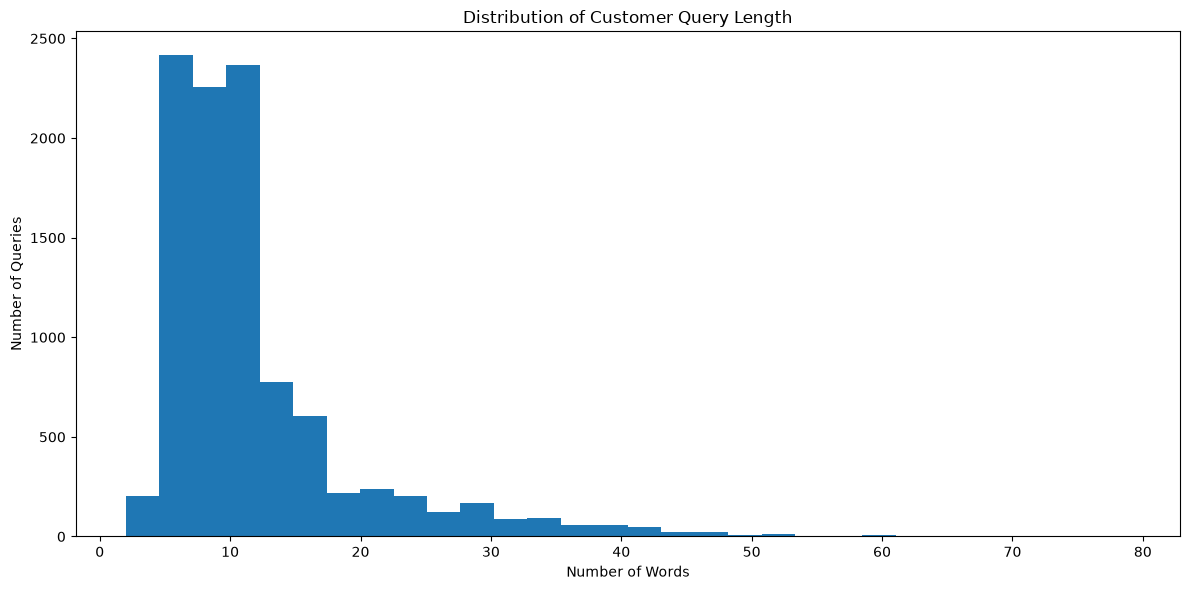

In [12]:
plt.figure(figsize=(12, 6))

plt.hist(
    train_df["word_count"],
    bins=30
)

plt.title("Distribution of Customer Query Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Queries")

plt.tight_layout()
plt.show()

In [ ]:
intent_length_stats = (
    train_df
    .groupby("label")["word_count"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

display(intent_length_stats.head(15))

,count,mean,median,min,max
label,,,,,
transfer_not_received_by_recipient,171,17.549708,12.0,4,58
transfer_fee_charged,172,17.395349,11.0,4,78
pending_cash_withdrawal,143,16.531469,11.0,3,64
failed_transfer,137,15.992701,10.0,3,54
direct_debit_payment_not_recognised,182,15.989011,12.0,3,58
transaction_charged_twice,175,15.988571,10.0,4,66
Refund_not_showing_up,162,15.808642,10.0,4,50
wrong_exchange_rate_for_cash_withdrawal,163,15.460123,12.0,5,39
cash_withdrawal_not_recognised,160,15.437500,12.0,4,40


In [14]:
sample_intents = [
    "cash_withdrawal",
    "cash_withdrawal_not_recognised",
    "card_payment_fee_charged",
    "cash_withdrawal_charge",
    "declined_card_payment",
    "pending_card_payment",
    "transaction_charged_twice"
]

for intent in sample_intents:
    print("\n" + "=" * 80)
    print(f"INTENT: {intent}")
    print("=" * 80)

    samples = train_df[
        train_df["label"] == intent
    ]["text"].sample(
        min(3, len(train_df[train_df["label"] == intent])),
        random_state=42
    )

    for i, text in enumerate(samples, 1):
        print(f"{i}. {text}")


INTENT: cash_withdrawal

INTENT: cash_withdrawal_not_recognised
1. There has a recent suspicious withdrawal on my bank account. Is it possible to freeze my card?
2. I am seeing in the App a some cash withdrawal that I did not do
3. i didnt put that money in my account

INTENT: card_payment_fee_charged
1. You promised no fees but now I've got one. What the hell!?
2. Why was there an extra charge because I used my card to pay?
3. I saw a fee on my app from one of my payments and I wasn't sure where it came from. Is there a way you can tell me when there's an additional fee for my payments?

INTENT: cash_withdrawal_charge
1. Why was there a fee on my cash withdrawal?
2. Hello, I wanted to get some more information about ATM Withdraw Fee. I have been withdrawing money for years and notice this charge on my account. I always thought it was no fee since its you guys ATM company that I am withdrawing. Can you please explain?
3. Why did I get a fee from the ATM?

INTENT: declined_card_payment

In [ ]:


train_intents = set(train_df["label"].unique())
test_intents = set(test_df["label"].unique())

print("TRAIN/TEST INTENT CONSISTENCY")
print("=" * 60)

print(f"Unique intents in training set: {len(train_intents)}")
print(f"Unique intents in test set: {len(test_intents)}")

print(f"\nIntents missing from test set: {train_intents - test_intents}")
print(f"Intents missing from training set: {test_intents - train_intents}")

if train_intents == test_intents:
    print("\n✓ All intents are present in both training and test sets.")
else:
    print("\n⚠ Train and test intent sets are different.")

TRAIN/TEST INTENT CONSISTENCY
Unique intents in training set: 77
Unique intents in test set: 77

Intents missing from test set: set()
Intents missing from training set: set()

✓ All intents are present in both training and test sets.
